# Order Estimation with simulated data

Simulate data, fit different HMMs with a varying number of hidden states. Compute BIC and AIC, explore dependence on sample size and difference between AR(1) model parameters.

## Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.hmm_ar_1_k_states import simulate_rs_ar1, forward_algorithm, fit_model
from methods.hmm_utils import fit_hmm_robust
from methods.plotting import set_style

set_style()


## Simulate data

In [11]:
T = 1000
seed = 1
# AR(1) parameters
beta = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])


y, states = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=seed)

print("")

## HMM modell med ulikt antall states

Estimerer HMM med 1 til 4 states. Lagrer AIC og BIC, samt likelihood. Bruker guess nær sanne parameter der det er mulig for raskere kode. Printer fremgang

In [12]:
K_vals = [1, 2, 3, 4]
results_all = []

for k in K_vals:
    print(f"Fitting K = {k}")

    try:
        result, params_hat = fit_hmm_robust(y, K=k, n_starts=5)
        loglik = -result.fun
        n_params = 2 * k + k * (k - 1)
        aic = -2 * loglik + 2 * n_params
        bic = -2 * loglik + np.log(len(y)) * n_params
    except RuntimeError as e:
        print(f"  Failed: {e}")
        loglik, aic, bic, params_hat = np.nan, np.nan, np.nan, None

    print(f"  loglik={loglik:.2f}, AIC={aic:.2f}, BIC={bic:.2f}")

    results_all.append({
        "K": k,
        "loglik": loglik,
        "AIC": aic,
        "BIC": bic,
        "params": params_hat
    })

results_df = pd.DataFrame(results_all).drop(columns="params")
print(results_df)


Fitting K = 1
  loglik=-1181.47, AIC=2366.94, BIC=2376.76
Fitting K = 2
  loglik=-1103.58, AIC=2219.15, BIC=2248.60
Fitting K = 3
  loglik=-1099.03, AIC=2222.05, BIC=2280.94
Fitting K = 4
  loglik=-1097.07, AIC=2234.13, BIC=2332.29
   K       loglik          AIC          BIC
0  1 -1181.469985  2366.939969  2376.755480
1  2 -1103.576527  2219.153055  2248.599586
2  3 -1099.025005  2222.050009  2280.943073
3  4 -1097.066783  2234.133567  2332.288672


# Undersøke hvordan sample size påvirker

In [13]:
sample_sizes = [200, 500, 1000, 2000]
n_rep = 10
K_vals = [1, 2, 3]

order_results = []

for T in sample_sizes:
    print(f"\nSample size T = {T}")
    aic_choices = []
    bic_choices = []

    for rep in range(n_rep):
        y, _ = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=1000 + rep)

        rep_results = []
        for k in K_vals:
            try:
                result, _ = fit_hmm_robust(y, K=k, n_starts=3, seed=rep)
                loglik = -result.fun
                n_params = 2 * k + k * (k - 1)
                aic = -2 * loglik + 2 * n_params
                bic = -2 * loglik + np.log(T) * n_params
            except RuntimeError:
                aic, bic = np.inf, np.inf

            rep_results.append({"K": k, "AIC": aic, "BIC": bic})

        best_k_aic = min(rep_results, key=lambda d: d["AIC"])["K"]
        best_k_bic = min(rep_results, key=lambda d: d["BIC"])["K"]
        aic_choices.append(best_k_aic)
        bic_choices.append(best_k_bic)

    order_results.append({
        "T": T,
        "AIC_correct_rate": np.mean(np.array(aic_choices) == 2),
        "BIC_correct_rate": np.mean(np.array(bic_choices) == 2),
        "AIC_choices": aic_choices,
        "BIC_choices": bic_choices,
    })
    print(f"  AIC correct: {order_results[-1]['AIC_correct_rate']:.2f}, BIC correct: {order_results[-1]['BIC_correct_rate']:.2f}")

order_df = pd.DataFrame(order_results)
print(order_df)



Sample size T = 200


/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: overflow encountered in exp
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:86: RuntimeWarning: invalid value encountered in divide
  beta = (1-np.exp(-beta_raw)) / (1 + np.exp(-beta_raw))
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:89: RuntimeWarning: overflow encountered in exp
  sigma = np.exp(sigma_raw)
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:94: RuntimeWarning: overflow encountered in exp
  row = np.exp(P_raw[i])
/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:95: RuntimeWarning: invalid value encountered in divide
  P[i] = row / np.sum(row)


  AIC correct: 0.90, BIC correct: 0.90

Sample size T = 500
  AIC correct: 0.60, BIC correct: 1.00

Sample size T = 1000
  AIC correct: 1.00, BIC correct: 1.00

Sample size T = 2000
  AIC correct: 0.90, BIC correct: 1.00
      T  AIC_correct_rate  BIC_correct_rate                     AIC_choices  \
0   200               0.9               0.9  [2, 2, 2, 2, 2, 2, 2, 3, 2, 2]   
1   500               0.6               1.0  [2, 3, 2, 3, 2, 2, 2, 3, 2, 3]   
2  1000               1.0               1.0  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   
3  2000               0.9               1.0  [2, 2, 2, 3, 2, 2, 2, 2, 2, 2]   

                      BIC_choices  
0  [2, 2, 2, 2, 2, 2, 2, 1, 2, 2]  
1  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]  
2  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]  
3  [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]  


# Different betas

In [14]:
beta1 = 0.2
beta2_vals = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sigma = np.array([0.5, 1.0])
P = np.array([[0.95, 0.05], [0.05, 0.95]])
T = 1000
K_vals = [1, 2, 3]

diff_results = []

for beta2 in beta2_vals:
    beta = np.array([beta1, beta2])
    diff = round(beta2 - beta1, 2)
    print(f"beta diff = {diff:.2f}")

    y, _ = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=1)

    rep_results = []
    for k in K_vals:
        try:
            result, _ = fit_hmm_robust(y, K=k, n_starts=3)
            loglik = -result.fun
            n_params = 2 * k + k * (k - 1)
            aic = -2 * loglik + 2 * n_params
            bic = -2 * loglik + np.log(T) * n_params
        except RuntimeError:
            aic, bic = np.inf, np.inf

        rep_results.append({"K": k, "AIC": aic, "BIC": bic})

    best_k_aic = min(rep_results, key=lambda d: d["AIC"])["K"]
    best_k_bic = min(rep_results, key=lambda d: d["BIC"])["K"]
    print(f"  AIC -> K={best_k_aic}, BIC -> K={best_k_bic}")

    diff_results.append({
        "beta_diff": diff,
        "best_k_aic": best_k_aic,
        "best_k_bic": best_k_bic
    })

diff_df = pd.DataFrame(diff_results)
print(diff_df)


beta diff = 0.10
  AIC -> K=2, BIC -> K=2
beta diff = 0.20
  AIC -> K=2, BIC -> K=2
beta diff = 0.30
  AIC -> K=2, BIC -> K=2
beta diff = 0.40
  AIC -> K=2, BIC -> K=2
beta diff = 0.50
  AIC -> K=2, BIC -> K=2
beta diff = 0.60
  AIC -> K=2, BIC -> K=2
   beta_diff  best_k_aic  best_k_bic
0        0.1           2           2
1        0.2           2           2
2        0.3           2           2
3        0.4           2           2
4        0.5           2           2
5        0.6           2           2


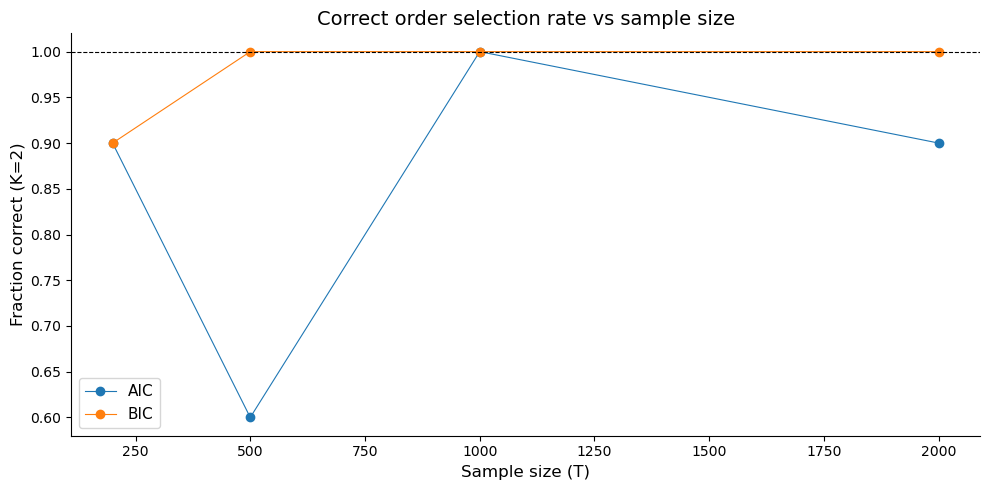

In [15]:
plt.plot(order_df["T"], order_df["AIC_correct_rate"], marker="o", label="AIC")
plt.plot(order_df["T"], order_df["BIC_correct_rate"], marker="o", label="BIC")
plt.axhline(1.0, linestyle="--", color="black", linewidth=0.8)
plt.title("Correct order selection rate vs sample size")
plt.xlabel("Sample size (T)")
plt.ylabel("Fraction correct (K=2)")
plt.legend()
plt.tight_layout()
# plt.savefig("../plots/order_selection_sample_size.pdf", bbox_inches="tight")
plt.show()


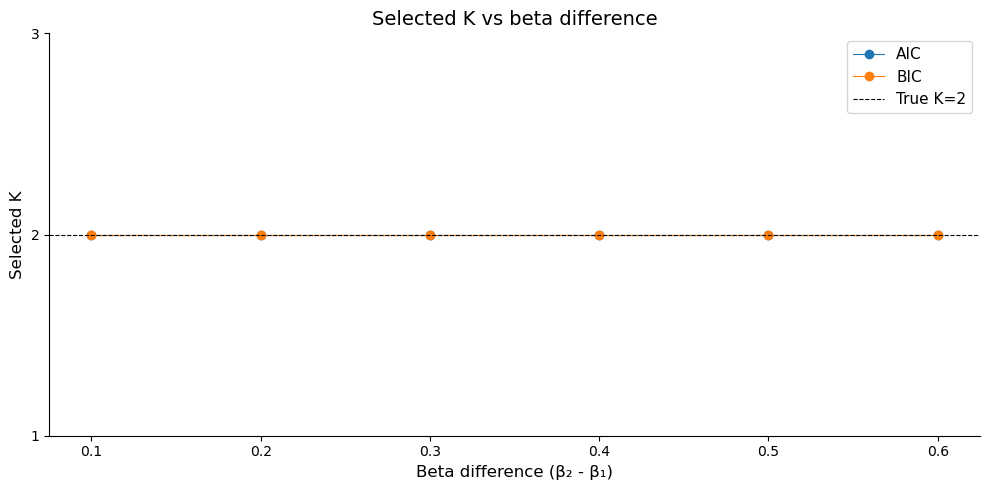

In [16]:
plt.plot(diff_df["beta_diff"], diff_df["best_k_aic"], marker="o", label="AIC")
plt.plot(diff_df["beta_diff"], diff_df["best_k_bic"], marker="o", label="BIC")
plt.axhline(2, linestyle="--", color="black", linewidth=0.8, label="True K=2")
plt.title("Selected K vs beta difference")
plt.xlabel("Beta difference (β₂ - β₁)")
plt.ylabel("Selected K")
plt.yticks([1, 2, 3])
plt.legend()
plt.tight_layout()
# plt.savefig("../plots/order_selection_beta_diff.pdf", bbox_inches="tight")
plt.show()


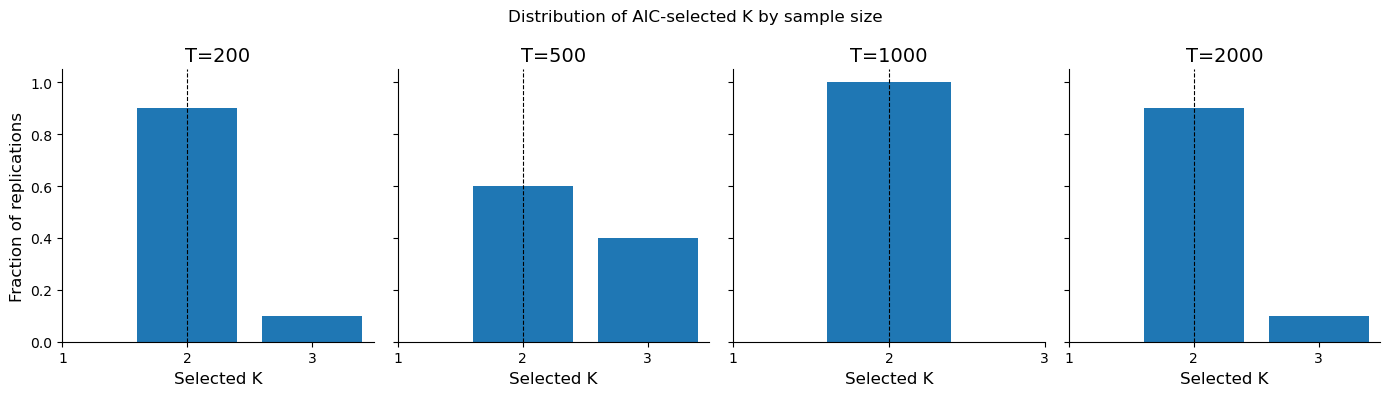

In [19]:
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(14, 4), sharey=True)

for ax, res in zip(axes, order_results):
    choices = res["AIC_choices"]
    unique, counts = np.unique(choices, return_counts=True)
    ax.bar(unique, counts / n_rep)
    ax.axvline(2, linestyle="--", color="black", linewidth=0.8)
    ax.set_title(f"T={res['T']}")
    ax.set_xlabel("Selected K")
    ax.set_xticks([1, 2, 3])

axes[0].set_ylabel("Fraction of replications")
fig.suptitle("Distribution of AIC-selected K by sample size")
plt.tight_layout()
plt.savefig("../plots/order_selection_distribution.pdf", bbox_inches="tight")
plt.show()


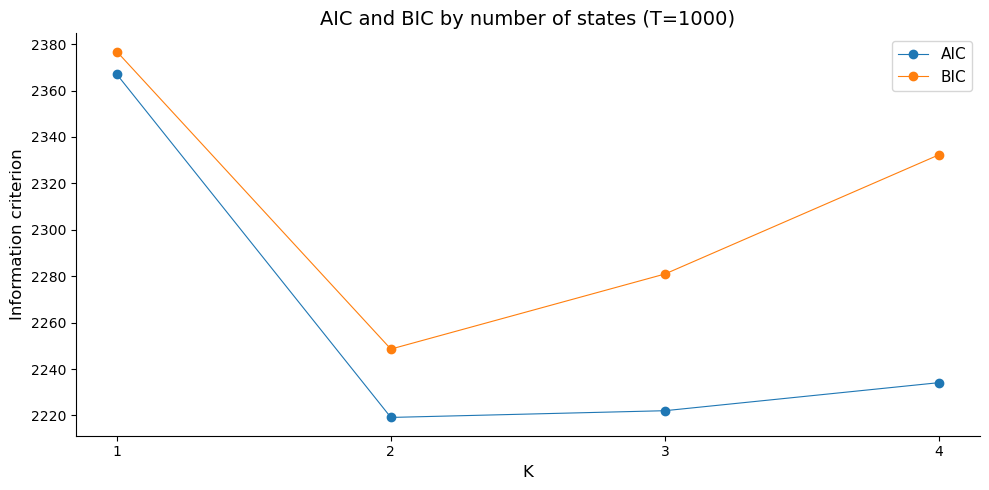

In [18]:
plot_df = pd.DataFrame(results_all).drop(columns="params")

plt.plot(plot_df["K"], plot_df["AIC"], marker="o", label="AIC")
plt.plot(plot_df["K"], plot_df["BIC"], marker="o", label="BIC")
plt.title("AIC and BIC by number of states (T=1000)")
plt.xlabel("K")
plt.ylabel("Information criterion")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.savefig("../plots/aic_bic_by_k.pdf", bbox_inches="tight")
plt.show()
